In [1]:
from __future__ import annotations
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
sns.set_theme(style='whitegrid', context='notebook')

In [3]:
color_1 = [40, 120, 60]
color_2 = [60, 50, 90]

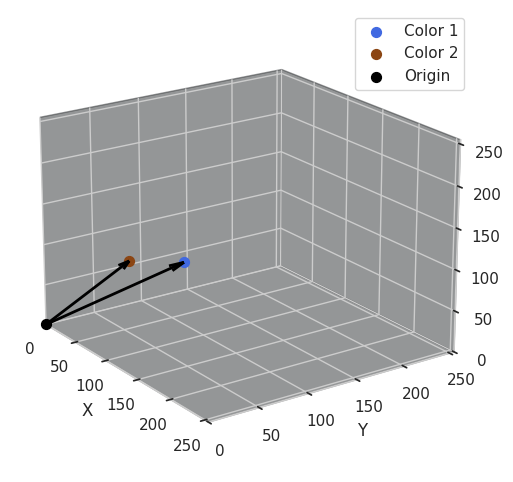

In [4]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")

ax.scatter(
    xs=color_1[0],
    ys=color_1[1],
    zs=color_1[2],
    label="Color 1",
    color="royalblue",
    s=50,
)

ax.scatter(
    xs=color_2[0],
    ys=color_2[1],
    zs=color_2[2],
    label="Color 2",
    color="saddlebrown",
    s=50,
)

ax.scatter(
    xs=0,
    ys=0,
    zs=0,
    label="Origin",
    color="black",
    s=50,
)

ax.quiver(
    0, 0, 0,
    color_1[0], color_1[1], color_1[2],
    color="black",
    arrow_length_ratio=0.1,
    linewidth=2,
)

ax.quiver(
    0, 0, 0,
    color_2[0], color_2[1], color_2[2],
    color="black",
    arrow_length_ratio=0.1,
    linewidth=2,
)

ax.set_xlim(0, 255)
ax.set_ylim(0, 255)
ax.set_zlim(0, 255)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.view_init(elev=20, azim=-35, roll=0)

ax.legend()

plt.show()

## Manhattan distance

In [5]:
L1 = [color_1[i] - color_2[i] for i in range(len(color_1))]
L1 = np.abs(L1).sum()

print(L1)

120


## Euclidean distance

In [6]:
L2 = [(color_1[i] - color_2[i]) ** 2 for i in range(len(color_1))]
L2 = np.sqrt(np.array(object=L2).sum())

print(L2)

78.74007874011811


## Cosine similarity

In [7]:
a = np.array(color_1)
b = np.array(color_2)
cosine = np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
print(cosine)

0.8271930531781648


## Dot product

In [8]:
dot = np.array(object=[color_1[i] * color_2[i] for i in range(len(color_1))]).sum()

print(dot)

13800


In [9]:
color_1 = [40, 120, 60]
color_2 = [60, 50, 90]
color_3 = [40, 100, 70]

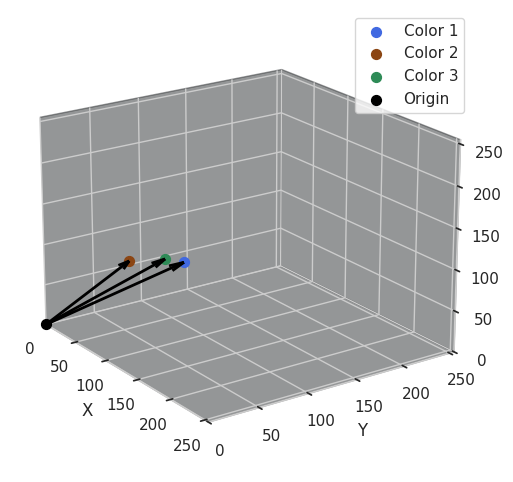

In [10]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")

ax.scatter(
    xs=color_1[0],
    ys=color_1[1],
    zs=color_1[2],
    label="Color 1",
    color="royalblue",
    s=50,
)

ax.scatter(
    xs=color_2[0],
    ys=color_2[1],
    zs=color_2[2],
    label="Color 2",
    color="saddlebrown",
    s=50,
)

ax.scatter(
    xs=color_3[0],
    ys=color_3[1],
    zs=color_3[2],
    label="Color 3",
    color="seagreen",
    s=50,
)

ax.scatter(
    xs=0,
    ys=0,
    zs=0,
    label="Origin",
    color="black",
    s=50,
)

ax.quiver(
    0, 0, 0,
    color_1[0], color_1[1], color_1[2],
    color="black",
    arrow_length_ratio=0.1,
    linewidth=2,
)

ax.quiver(
    0, 0, 0,
    color_2[0], color_2[1], color_2[2],
    color="black",
    arrow_length_ratio=0.1,
    linewidth=2,
)

ax.quiver(
    0, 0, 0,
    color_3[0], color_3[1], color_3[2],
    color="black",
    arrow_length_ratio=0.1,
    linewidth=2,
)

ax.set_xlim(0, 255)
ax.set_ylim(0, 255)
ax.set_zlim(0, 255)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.view_init(elev=20, azim=-35, roll=0)

ax.legend()

plt.show()

In [1]:
import json
import requests
from getpass import getpass
import os

In [2]:
os.environ['OPENAI_API_KEY'] = getpass('Provide OPEN_API_KEY')

In [20]:
response = requests.get(
    url="https://raw.githubusercontent.com/weaviate-tutorials/quickstart/main/data/jeopardy_tiny.json"
)

data = json.loads(s=response.text)

In [21]:
print(type(data), len(data))
print(json.dumps(obj=data[0], indent=2))

<class 'list'> 10
{
  "Category": "SCIENCE",
  "Question": "This organ removes excess glucose from the blood & stores it as glycogen",
  "Answer": "Liver"
}


In [22]:
def json_print(data):
    print(json.dumps(data, indent=2))

In [23]:
json_print(data)

[
  {
    "Category": "SCIENCE",
    "Question": "This organ removes excess glucose from the blood & stores it as glycogen",
    "Answer": "Liver"
  },
  {
    "Category": "ANIMALS",
    "Question": "It's the only living mammal in the order Proboseidea",
    "Answer": "Elephant"
  },
  {
    "Category": "ANIMALS",
    "Question": "The gavial looks very much like a crocodile except for this bodily feature",
    "Answer": "the nose or snout"
  },
  {
    "Category": "ANIMALS",
    "Question": "Weighing around a ton, the eland is the largest species of this animal in Africa",
    "Answer": "Antelope"
  },
  {
    "Category": "ANIMALS",
    "Question": "Heaviest of all poisonous snakes is this North American rattlesnake",
    "Answer": "the diamondback rattler"
  },
  {
    "Category": "SCIENCE",
    "Question": "2000 news: the Gunnison sage grouse isn't just another northern sage grouse, but a new one of this classification",
    "Answer": "species"
  },
  {
    "Category": "SCIENCE",
   

In [8]:
import os
import weaviate
from weaviate.embedded import EmbeddedOptions

In [24]:
def load_tiny_joepardy():
    url = "https://raw.githubusercontent.com/weaviate-tutorials/quickstart/main/data/jeopardy_tiny.json"
    return requests.get(url).json()

In [38]:
def load_joepardy_1k():
    url = "https://raw.githubusercontent.com/weaviate-tutorials/intro-workshop/main/data/jeopardy_1k.json"
    return requests.get(url).json()

In [11]:
import os
import weaviate
from weaviate.exceptions import WeaviateStartUpError


def connect_embedded_or_local():
    headers = {
        "X-OpenAI-Api-Key": os.environ["OPENAI_API_KEY"],
    }

    try:
        return weaviate.connect_to_embedded(
            headers=headers,
            environment_variables={
                "ENABLE_MODULES": "text2vec-openai,generative-openai",
            },
        )
    except WeaviateStartUpError:
        return weaviate.connect_to_local(
            port=8079,
            grpc_port=50050,
            headers=headers,
        )

In [12]:
data = load_tiny_joepardy()
json_print(data)

[
  {
    "Category": "SCIENCE",
    "Question": "This organ removes excess glucose from the blood & stores it as glycogen",
    "Answer": "Liver"
  },
  {
    "Category": "ANIMALS",
    "Question": "It's the only living mammal in the order Proboseidea",
    "Answer": "Elephant"
  },
  {
    "Category": "ANIMALS",
    "Question": "The gavial looks very much like a crocodile except for this bodily feature",
    "Answer": "the nose or snout"
  },
  {
    "Category": "ANIMALS",
    "Question": "Weighing around a ton, the eland is the largest species of this animal in Africa",
    "Answer": "Antelope"
  },
  {
    "Category": "ANIMALS",
    "Question": "Heaviest of all poisonous snakes is this North American rattlesnake",
    "Answer": "the diamondback rattler"
  },
  {
    "Category": "SCIENCE",
    "Question": "2000 news: the Gunnison sage grouse isn't just another northern sage grouse, but a new one of this classification",
    "Answer": "species"
  },
  {
    "Category": "SCIENCE",
   

In [26]:
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

In [13]:
client = connect_embedded_or_local()
print(client.is_ready())

{"build_git_commit":"","build_go_version":"go1.24.3","build_image_tag":"","build_wv_version":"1.30.5","level":"warning","log_level_env":"","msg":"log level not recognized, defaulting to info","time":"2026-05-18T21:29:54+02:00"}
{"action":"startup","build_git_commit":"","build_go_version":"go1.24.3","build_image_tag":"","build_wv_version":"1.30.5","level":"info","msg":"Feature flag LD integration disabled: could not locate WEAVIATE_LD_API_KEY env variable","time":"2026-05-18T21:29:54+02:00"}
{"action":"startup","build_git_commit":"","build_go_version":"go1.24.3","build_image_tag":"","build_wv_version":"1.30.5","default_vectorizer_module":"none","level":"info","msg":"the default vectorizer modules is set to \"none\", as a result all new schema classes without an explicit vectorizer setting, will use this vectorizer","time":"2026-05-18T21:29:54+02:00"}
{"action":"startup","auto_schema_enabled":{},"build_git_commit":"","build_go_version":"go1.24.3","build_image_tag":"","build_wv_version":"

True


In [14]:
client.close()

{"action":"restapi_management","build_git_commit":"","build_go_version":"go1.24.3","build_image_tag":"","build_wv_version":"1.30.5","level":"info","msg":"Shutting down... ","time":"2026-05-18T21:31:24+02:00","version":"1.30.5"}
{"action":"restapi_management","build_git_commit":"","build_go_version":"go1.24.3","build_image_tag":"","build_wv_version":"1.30.5","level":"info","msg":"Stopped serving weaviate at http://127.0.0.1:8079","time":"2026-05-18T21:31:24+02:00","version":"1.30.5"}
{"action":"telemetry_push","build_git_commit":"","build_go_version":"go1.24.3","build_image_tag":"","build_wv_version":"1.30.5","level":"info","msg":"telemetry terminated","payload":"\u0026{MachineID:c2df1906-8678-44f4-aa22-ad499d1018c9 Type:TERMINATE Version:1.30.5 ObjectsCount:0 OS:linux Arch:amd64 UsedModules:[] CollectionsCount:0}","time":"2026-05-18T21:31:24+02:00"}
{"build_git_commit":"","build_go_version":"go1.24.3","build_image_tag":"","build_wv_version":"1.30.5","level":"info","msg":"closing raft F

In [15]:
client = connect_embedded_or_local()
print(client.is_ready())

{"build_git_commit":"","build_go_version":"go1.24.3","build_image_tag":"","build_wv_version":"1.30.5","level":"warning","log_level_env":"","msg":"log level not recognized, defaulting to info","time":"2026-05-18T21:34:33+02:00"}
{"action":"startup","build_git_commit":"","build_go_version":"go1.24.3","build_image_tag":"","build_wv_version":"1.30.5","level":"info","msg":"Feature flag LD integration disabled: could not locate WEAVIATE_LD_API_KEY env variable","time":"2026-05-18T21:34:33+02:00"}
{"action":"startup","build_git_commit":"","build_go_version":"go1.24.3","build_image_tag":"","build_wv_version":"1.30.5","default_vectorizer_module":"none","level":"info","msg":"the default vectorizer modules is set to \"none\", as a result all new schema classes without an explicit vectorizer setting, will use this vectorizer","time":"2026-05-18T21:34:33+02:00"}
{"action":"startup","auto_schema_enabled":{},"build_git_commit":"","build_go_version":"go1.24.3","build_image_tag":"","build_wv_version":"

True


In [18]:
import weaviate.classes as wvc
from getpass import getpass

In [17]:
def recreate_question_collection(client, *, include_round=False, generative=False):
    if client.collections.exists('Question'):
        client.collections.delete('Question')


    properties = [
        wvc.config.Property(name='question', data_type=wvc.config.DataType.TEXT),
        wvc.config.Property(name='answer', data_type=wvc.config.DataType.TEXT),
        wvc.config.Property(name='category', data_type=wvc.config.DataType.TEXT),

    ]

    if include_round:
        properties.append(wvc.config.Property(name='round', data_type=wvc.config.DataType.TEXT))

    kwargs = {}

    if generative:
        kwargs['generative_config'] = wvc.config.Configure.Generative.openai(model='gpt-4o-mini')

    return client.collections.create(
        name="Question",
        vector_config=wvc.config.Configure.Vectors.text2vec_openai(
            model="text-embedding-3-small"
        ),
        properties=properties,
        **kwargs,
    )

In [19]:
questions = recreate_question_collection(client)
print(questions.name)

Question


In [26]:
def import_questions(collection, data, *, include_round=False):
    objects = []

    for d in data:
        obj = {
            'question': d['Question'],
            'answer': d['Answer'],
            'category': d['Category']
        }

        if include_round:
            obj['round'] = d.get('Round', '')

        objects.append(obj)

    result = collection.data.insert_many(objects)
    if result.errors:
        print('Import Error')
        json_print(result.errors)
    return result

In [27]:
data

[{'Category': 'SCIENCE',
  'Question': 'This organ removes excess glucose from the blood & stores it as glycogen',
  'Answer': 'Liver'},
 {'Category': 'ANIMALS',
  'Question': "It's the only living mammal in the order Proboseidea",
  'Answer': 'Elephant'},
 {'Category': 'ANIMALS',
  'Question': 'The gavial looks very much like a crocodile except for this bodily feature',
  'Answer': 'the nose or snout'},
 {'Category': 'ANIMALS',
  'Question': 'Weighing around a ton, the eland is the largest species of this animal in Africa',
  'Answer': 'Antelope'},
 {'Category': 'ANIMALS',
  'Question': 'Heaviest of all poisonous snakes is this North American rattlesnake',
  'Answer': 'the diamondback rattler'},
 {'Category': 'SCIENCE',
  'Question': "2000 news: the Gunnison sage grouse isn't just another northern sage grouse, but a new one of this classification",
  'Answer': 'species'},
 {'Category': 'SCIENCE',
  'Question': 'A metal that is ductile can be pulled into this while cold & under pressur

In [28]:
import_questions(questions, data)
count = questions.aggregate.over_all(total_count=True)

print('object', count.total_count)

object 10


In [29]:
response = questions.query.fetch_objects(
    limit=3,
    return_properties=['question', 'answer', 'category']
)

for obj in response.objects:
    json_print(obj.properties)

{
  "answer": "DNA",
  "category": "SCIENCE",
  "question": "In 1953 Watson & Crick built a model of the molecular structure of this, the gene-carrying substance"
}
{
  "answer": "Sound barrier",
  "category": "SCIENCE",
  "question": "In 70-degree air, a plane traveling at about 1,130 feet per second breaks it"
}
{
  "answer": "wire",
  "category": "SCIENCE",
  "question": "A metal that is ductile can be pulled into this while cold & under pressure"
}


In [30]:
client.close()

{"action":"restapi_management","build_git_commit":"","build_go_version":"go1.24.3","build_image_tag":"","build_wv_version":"1.30.5","level":"info","msg":"Shutting down... ","time":"2026-05-18T22:15:20+02:00","version":"1.30.5"}
{"action":"restapi_management","build_git_commit":"","build_go_version":"go1.24.3","build_image_tag":"","build_wv_version":"1.30.5","level":"info","msg":"Stopped serving weaviate at http://127.0.0.1:8079","time":"2026-05-18T22:15:20+02:00","version":"1.30.5"}
{"action":"telemetry_push","build_git_commit":"","build_go_version":"go1.24.3","build_image_tag":"","build_wv_version":"1.30.5","level":"info","msg":"telemetry terminated","payload":"\u0026{MachineID:c0222b32-4602-4d3e-967b-de8ec66a0486 Type:TERMINATE Version:1.30.5 ObjectsCount:10 OS:linux Arch:amd64 UsedModules:[text2vec-openai] CollectionsCount:1}","time":"2026-05-18T22:15:21+02:00"}
{"build_git_commit":"","build_go_version":"go1.24.3","build_image_tag":"","build_wv_version":"1.30.5","level":"info","msg"

In [31]:
client = connect_embedded_or_local()
print(client.is_ready())

{"build_git_commit":"","build_go_version":"go1.24.3","build_image_tag":"","build_wv_version":"1.30.5","level":"warning","log_level_env":"","msg":"log level not recognized, defaulting to info","time":"2026-05-18T22:16:45+02:00"}
{"action":"startup","build_git_commit":"","build_go_version":"go1.24.3","build_image_tag":"","build_wv_version":"1.30.5","level":"info","msg":"Feature flag LD integration disabled: could not locate WEAVIATE_LD_API_KEY env variable","time":"2026-05-18T22:16:45+02:00"}
{"action":"startup","build_git_commit":"","build_go_version":"go1.24.3","build_image_tag":"","build_wv_version":"1.30.5","default_vectorizer_module":"none","level":"info","msg":"the default vectorizer modules is set to \"none\", as a result all new schema classes without an explicit vectorizer setting, will use this vectorizer","time":"2026-05-18T22:16:45+02:00"}
{"action":"startup","auto_schema_enabled":{},"build_git_commit":"","build_go_version":"go1.24.3","build_image_tag":"","build_wv_version":"

True


{"action":"telemetry_push","build_git_commit":"","build_go_version":"go1.24.3","build_image_tag":"","build_wv_version":"1.30.5","level":"info","msg":"telemetry started","payload":"\u0026{MachineID:208c87e8-d7c1-4f8c-a0a8-0b33539be9ce Type:INIT Version:1.30.5 ObjectsCount:0 OS:linux Arch:amd64 UsedModules:[text2vec-openai] CollectionsCount:1}","time":"2026-05-18T22:16:47+02:00"}


In [32]:
questions = client.collections.use('Question')

In [33]:
response = questions.query.fetch_objects(
    limit=1,
    return_properties=['question', 'answer', 'category'],
    include_vector=True
)

for obj in response.objects:
    json_print(obj.properties)
    print(obj.vector['default'])
    print(len(obj.vector['default']))

{
  "answer": "DNA",
  "category": "SCIENCE",
  "question": "In 1953 Watson & Crick built a model of the molecular structure of this, the gene-carrying substance"
}
[0.01995849609375, 0.04193115234375, -0.026519775390625, 0.065673828125, -0.04559326171875, -0.0013942718505859375, 0.0194244384765625, -0.0531005859375, -0.039642333984375, -0.0170135498046875, 0.05999755859375, -0.01076507568359375, 0.01094818115234375, -0.0161590576171875, -0.043670654296875, -0.01107025146484375, 0.0308685302734375, 0.01666259765625, 0.00275421142578125, -0.002681732177734375, 0.02606201171875, 9.757280349731445e-05, 0.01239776611328125, 0.0219573974609375, 0.060455322265625, -0.0406494140625, -0.019927978515625, -0.0121917724609375, 0.007686614990234375, -0.0233001708984375, -0.0023288726806640625, -0.03680419921875, 0.046417236328125, -0.0055694580078125, -0.022369384765625, 0.035736083984375, 0.019805908203125, -0.016845703125, -0.0006079673767089844, 0.04144287109375, 0.00447845458984375, -0.0147933

In [34]:
from weaviate.classes.query import MetadataQuery

response = questions.query.near_text(
    query="biology",
    limit=2,
    return_properties=["question", "answer", "category"],
    return_metadata=MetadataQuery(distance=True),
)

for obj in response.objects:
    json_print(data=obj.properties)
    print(obj.metadata.distance)

{
  "answer": "DNA",
  "category": "SCIENCE",
  "question": "In 1953 Watson & Crick built a model of the molecular structure of this, the gene-carrying substance"
}
0.7428681254386902
{
  "answer": "species",
  "category": "SCIENCE",
  "question": "2000 news: the Gunnison sage grouse isn't just another northern sage grouse, but a new one of this classification"
}
0.7866588234901428


In [35]:
from weaviate.classes.query import MetadataQuery

response = questions.query.near_text(
    query="animals",
    limit=10,
    return_properties=["question", "answer", "category"],
    return_metadata=MetadataQuery(distance=True),
)

for obj in response.objects:
    print(obj.metadata.distance, obj.properties['question'], '=>', obj.properties['answer'])

0.5862237811088562 It's the only living mammal in the order Proboseidea => Elephant
0.6441107988357544 Weighing around a ton, the eland is the largest species of this animal in Africa => Antelope
0.6861038208007812 The gavial looks very much like a crocodile except for this bodily feature => the nose or snout
0.7377046942710876 2000 news: the Gunnison sage grouse isn't just another northern sage grouse, but a new one of this classification => species
0.7504521012306213 Heaviest of all poisonous snakes is this North American rattlesnake => the diamondback rattler
0.8291488885879517 This organ removes excess glucose from the blood & stores it as glycogen => Liver
0.8360293507575989 A metal that is ductile can be pulled into this while cold & under pressure => wire
0.8549216985702515 In 1953 Watson & Crick built a model of the molecular structure of this, the gene-carrying substance => DNA
0.8568268418312073 Changes in the tropospheric layer of this are what gives us weather => the atmosp

In [36]:
from weaviate.classes.query import MetadataQuery

response = questions.query.near_text(
    query="animals",
    distance=0.24,
    limit=10,
    return_properties=["question", "answer", "category"],
    return_metadata=MetadataQuery(distance=True),
)

for obj in response.objects:
    print(obj.metadata.distance, obj.properties['question'], '=>', obj.properties['answer'])

In [37]:
client.close()

{"action":"restapi_management","build_git_commit":"","build_go_version":"go1.24.3","build_image_tag":"","build_wv_version":"1.30.5","level":"info","msg":"Shutting down... ","time":"2026-05-18T22:34:23+02:00","version":"1.30.5"}
{"action":"restapi_management","build_git_commit":"","build_go_version":"go1.24.3","build_image_tag":"","build_wv_version":"1.30.5","level":"info","msg":"Stopped serving weaviate at http://127.0.0.1:8079","time":"2026-05-18T22:34:23+02:00","version":"1.30.5"}
{"action":"telemetry_push","build_git_commit":"","build_go_version":"go1.24.3","build_image_tag":"","build_wv_version":"1.30.5","level":"info","msg":"telemetry terminated","payload":"\u0026{MachineID:208c87e8-d7c1-4f8c-a0a8-0b33539be9ce Type:TERMINATE Version:1.30.5 ObjectsCount:10 OS:linux Arch:amd64 UsedModules:[text2vec-openai] CollectionsCount:1}","time":"2026-05-18T22:34:23+02:00"}
{"build_git_commit":"","build_go_version":"go1.24.3","build_image_tag":"","build_wv_version":"1.30.5","level":"info","msg"

In [48]:
data = load_joepardy_1k()
print(len(data))
json_print(data[0])

1000
{
  "Air Date": "2006-11-08",
  "Round": "Double Jeopardy!",
  "Value": 800,
  "Category": "AMERICAN HISTORY",
  "Question": "Abraham Lincoln died across the street from this theatre on April 15, 1865",
  "Answer": "Ford's Theatre (the Ford Theatre accepted)"
}


In [49]:
client = connect_embedded_or_local()
questions = recreate_question_collection(client, include_round=True)

{"build_git_commit":"","build_go_version":"go1.24.3","build_image_tag":"","build_wv_version":"1.30.5","level":"warning","log_level_env":"","msg":"log level not recognized, defaulting to info","time":"2026-05-18T22:56:05+02:00"}
{"action":"startup","build_git_commit":"","build_go_version":"go1.24.3","build_image_tag":"","build_wv_version":"1.30.5","level":"info","msg":"Feature flag LD integration disabled: could not locate WEAVIATE_LD_API_KEY env variable","time":"2026-05-18T22:56:05+02:00"}
{"action":"startup","build_git_commit":"","build_go_version":"go1.24.3","build_image_tag":"","build_wv_version":"1.30.5","default_vectorizer_module":"none","level":"info","msg":"the default vectorizer modules is set to \"none\", as a result all new schema classes without an explicit vectorizer setting, will use this vectorizer","time":"2026-05-18T22:56:05+02:00"}
{"action":"startup","auto_schema_enabled":{},"build_git_commit":"","build_go_version":"go1.24.3","build_image_tag":"","build_wv_version":"

In [50]:
import_questions(questions, data, include_round=True)

BatchObjectReturn(_all_responses=[UUID('caff2723-3bc9-44ef-bab5-4c3d9180493d'), UUID('c1ddb013-6a77-4365-9b8f-eac281cc9119'), UUID('1e6a81a0-dd73-4d95-9b88-0e0a12e71fbb'), UUID('64603add-ddb2-4626-b085-41f33d0e3ace'), UUID('bf5248b0-0b53-4e41-bad0-51423c5b80f1'), UUID('9a6716ba-7d9d-47c0-8f20-42e886e1557e'), UUID('beeeaada-cd8e-43a5-8032-d823baa3420a'), UUID('a8f7fe2f-e161-4e03-8421-6baf07a37142'), UUID('29bcac82-f65a-427e-85f2-5ce0533515bf'), UUID('50095a3b-f460-4d99-8677-26ee84d9cc9d'), UUID('635f588d-e5ae-4148-91af-5992182b8c49'), UUID('bf7f5bed-9ee2-43ed-9a98-074f03bf0722'), UUID('890c97da-40c3-479f-9fa1-48c4b03a59b7'), UUID('df08a4b8-5b6e-4528-905b-3192b714d06a'), UUID('3a40f88c-4f3f-41ca-be32-68e69b3881dd'), UUID('c8ad974c-7844-4428-9895-01c064d94c5a'), UUID('c55f56f2-6c71-4124-a7fc-e1ecd5623567'), UUID('f1a2503c-dac7-47f2-800a-309f6678463c'), UUID('adcafc0e-fe62-4364-a4ee-0fb8a36b8a55'), UUID('2a627faa-f4c1-4021-847b-e5704ce94928'), UUID('600b278b-e0ce-4d99-8953-ef73bdf0efbb'), 

In [51]:
questions.aggregate.over_all(total_count=True).total_count

1000

In [52]:
response = questions.query.near_text(
    query='spicy food',

    limit=4,
    return_properties=["question", "answer", "round"],
    return_metadata=MetadataQuery(distance=True),
)

for obj in response.objects:
    print("distance", obj.metadata.distance)
    json_print(obj.properties)

distance 0.6253281235694885
{
  "answer": "tripe",
  "question": "Popular in Pennsylvania, pepper pot is a peppery soup made from this stomach lining",
  "round": "Jeopardy!"
}
distance 0.6496911644935608
{
  "answer": "Yellow",
  "question": "A wax bean is a variety of green bean that's this color",
  "round": "Double Jeopardy!"
}
distance 0.6554131507873535
{
  "answer": "Chiles Rellenos",
  "question": "The name of this Mexican dish made with chiles & cheese translates to \"stuffed peppers\"",
  "round": "Jeopardy!"
}
distance 0.679579496383667
{
  "answer": "licorice",
  "question": "Herbs anise & fennel resemble the flavor of this common black candy",
  "round": "Jeopardy!"
}


In [55]:
response = questions.query.near_text(
    query='spicy food',

    limit=4,
    return_properties=["question", "answer", "round"],
    return_metadata=MetadataQuery(distance=True),
)

for obj in response.objects:
    print("distance", obj.metadata.distance)
    json_print(obj.properties)



distance 0.6253281235694885
{
  "answer": "tripe",
  "question": "Popular in Pennsylvania, pepper pot is a peppery soup made from this stomach lining",
  "round": "Jeopardy!"
}
distance 0.6496911644935608
{
  "answer": "Yellow",
  "question": "A wax bean is a variety of green bean that's this color",
  "round": "Double Jeopardy!"
}
distance 0.6554131507873535
{
  "answer": "Chiles Rellenos",
  "question": "The name of this Mexican dish made with chiles & cheese translates to \"stuffed peppers\"",
  "round": "Jeopardy!"
}
distance 0.679579496383667
{
  "answer": "licorice",
  "question": "Herbs anise & fennel resemble the flavor of this common black candy",
  "round": "Jeopardy!"
}


In [54]:
from weaviate.classes.query import Filter, MetadataQuery

response = questions.query.near_text(
    query="spicy food recipes",
    filters=Filter.by_property("round").equal("Double Jeopardy!"),
    limit=4,
    return_properties=["question", "answer", "round"],
    return_metadata=MetadataQuery(distance=True),
)

for obj in response.objects:
    print("distance", obj.metadata.distance)
    json_print(obj.properties)

distance 0.7069010734558105
{
  "answer": "Yellow",
  "question": "A wax bean is a variety of green bean that's this color",
  "round": "Double Jeopardy!"
}
distance 0.7212643623352051
{
  "answer": "\"Jambalaya\"",
  "question": "This Creole concoction of meat & seafood is so good Hank Williams wrote a song about it in 1952",
  "round": "Double Jeopardy!"
}
distance 0.7214321494102478
{
  "answer": "English/burpless/seedless",
  "question": "This type of cucumber is only grown under artificial conditions in hothouses",
  "round": "Double Jeopardy!"
}
distance 0.7422679662704468
{
  "answer": "Herring",
  "question": "The Bismarck type of this fish is made of fillets cured in vinegar, salt & onions",
  "round": "Double Jeopardy!"
}


In [56]:
client.close()

{"action":"restapi_management","build_git_commit":"","build_go_version":"go1.24.3","build_image_tag":"","build_wv_version":"1.30.5","level":"info","msg":"Shutting down... ","time":"2026-05-18T23:31:12+02:00","version":"1.30.5"}
{"action":"restapi_management","build_git_commit":"","build_go_version":"go1.24.3","build_image_tag":"","build_wv_version":"1.30.5","level":"info","msg":"Stopped serving weaviate at http://127.0.0.1:8079","time":"2026-05-18T23:31:12+02:00","version":"1.30.5"}
{"action":"telemetry_push","build_git_commit":"","build_go_version":"go1.24.3","build_image_tag":"","build_wv_version":"1.30.5","level":"info","msg":"telemetry terminated","payload":"\u0026{MachineID:8c961540-4c98-4d34-830e-f04e1cacd61a Type:TERMINATE Version:1.30.5 ObjectsCount:1000 OS:linux Arch:amd64 UsedModules:[text2vec-openai] CollectionsCount:1}","time":"2026-05-18T23:31:13+02:00"}
{"build_git_commit":"","build_go_version":"go1.24.3","build_image_tag":"","build_wv_version":"1.30.5","level":"info","ms